# Sequential Data and Recurrent Neural Networks

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as snss
import pandas as pd
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.axisbelow'] = True
plt.rcParams['figure.dpi'] = 150

In [2]:
# Check available hardware
import torch
if torch.cuda.is_available():
    print(f'GPU is available, using GPU {torch.cuda.get_device_name(0)}')
    device = torch.device('cuda')
elif torch.mps.is_available():
    print(f'Apple Metal Performance Shaders framework is available, using {torch.device("mps")}')
    device = torch.device('mps')
else:
    print(f'Hardware acceleration not available, using CPU')
    device = torch.device('cpu')

GPU is available, using GPU Tesla T4


## Example with toy sequences

In [3]:
x_seq = torch.FloatTensor([[1,], [2,], [3,]])
x_seq = x_seq.repeat(1, 2)
print(f"x_seq has shape {x_seq.shape} which means it is a sequence of {x_seq.shape[0]} {x_seq.shape[1]}-dimensional vectors")

x_seq has shape torch.Size([3, 2]) which means it is a sequence of 3 2-dimensional vectors


An RNN has a hidden state $h^{(t)}$ which receives two inputs: 

- the previous hidden state $h^{(t-1)}$
- the current input $x^{(t)}$

In [4]:
import torch.nn as nn
import torch.nn.functional as F

class RNN_Cell(nn.Module):
    def __init__(self, input_size=2, hidden_size=4):
        super().__init__()

        self.hidden_size = hidden_size

        # Weight and bias connecting previous hidden state
        self.w_hh = nn.Parameter(torch.randn(size=(hidden_size, hidden_size)))
        self.b_hh = nn.Parameter(torch.zeros(hidden_size))

        # Weight and bias connecting inputs
        self.w_ih = nn.Parameter(torch.randn(size=(hidden_size, input_size)))
        self.b_ih = nn.Parameter(torch.zeros(hidden_size))

    def forward(self, x):
        """ x has size [B, t, c]
        """
        B, T, C = x.shape
        ht = torch.zeros([B, self.hidden_size], device=x.device, dtype=x.dtype)
        ot = torch.zeros([B, T, self.hidden_size], device=x.device, dtype=x.dtype)
        for t in range(T):
            xt = x[:, t, :]
            print(f'At t = {t}')
            print(f'\tInput = {xt.numpy()}')
            ht = xt @ self.w_ih.T + self.b_ih + \
                 ht @ self.w_hh.T + self.b_hh
            ht = F.tanh(ht)
            print(f'\tHidden = {ht.detach().numpy()}')
            ot[:, t, :] = ht
        return ot, ht

torch_RNN = nn.RNN(input_size=2, hidden_size=4, batch_first=True)
print("Ground truth")
print("------------")
output, hidden = torch_RNN(x_seq[None])
print(f"Output is of size {output.shape}")
print(output)
print()
print(f"Last hidden is of size {hidden.shape}")
print(hidden)

print()
print("Our implementation")
print("------------------")
np.set_printoptions(precision=4)
cell = RNN_Cell()
with torch.no_grad():
    cell.w_hh[:] = torch_RNN.weight_hh_l0
    cell.b_hh[:] = torch_RNN.bias_hh_l0
    cell.w_ih[:] = torch_RNN.weight_ih_l0
    cell.b_ih[:] = torch_RNN.bias_ih_l0

output, hidden = cell(x_seq[None])

print()
print(f"Output is of size {output.shape}")
print(output)
print()
print(f"Last hidden is of size {hidden.shape}")
print(hidden)       

Ground truth
------------
Output is of size torch.Size([1, 3, 4])
tensor([[[-0.6248,  0.5047,  0.4112, -0.6649],
         [-0.4835,  0.8271,  0.2913, -0.8987],
         [-0.4499,  0.8992,  0.6260, -0.9621]]], grad_fn=<TransposeBackward1>)

Last hidden is of size torch.Size([1, 1, 4])
tensor([[[-0.4499,  0.8992,  0.6260, -0.9621]]], grad_fn=<StackBackward0>)

Our implementation
------------------
At t = 0
	Input = [[1. 1.]]
	Hidden = [[-0.6248  0.5047  0.4112 -0.6649]]
At t = 1
	Input = [[2. 2.]]
	Hidden = [[-0.4835  0.8271  0.2913 -0.8987]]
At t = 2
	Input = [[3. 3.]]
	Hidden = [[-0.4499  0.8992  0.626  -0.9621]]

Output is of size torch.Size([1, 3, 4])
tensor([[[-0.6248,  0.5047,  0.4112, -0.6649],
         [-0.4835,  0.8271,  0.2913, -0.8987],
         [-0.4499,  0.8992,  0.6260, -0.9621]]], grad_fn=<CopySlices>)

Last hidden is of size torch.Size([1, 4])
tensor([[-0.4499,  0.8992,  0.6260, -0.9621]], grad_fn=<TanhBackward0>)


## Classification example: IMDB sentiment database

In [5]:
# !pip install --upgrade pyarrow datasets
!pip install datasets

In [6]:
from datasets import load_dataset

imdb_dataset = load_dataset("stanfordnlp/imdb")

In [7]:
imdb_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [8]:
from torch.utils.data import Dataset, random_split, DataLoader

class IMDBDataset(Dataset):
    def __init__(self, hf_data):
        self.hf_data = hf_data

    def __len__(self):
        return len(self.hf_data)

    def __getitem__(self, idx):
        # We can return dicts in addition to tuples
        return {
            'text': self.hf_data[idx]['text'],
            'label': self.hf_data[idx]['label']
        }

train_val_dataset = imdb_dataset['train']#IMDBDataset(imdb_dataset['train'])
train_dataset, val_dataset = random_split(train_val_dataset, lengths=[0.8, 0.2])
test_dataset = imdb_dataset['test']

loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
batch = next(iter(loader))
print(batch['text'], batch['label'])

["Not as bad as some are making it out to be, though obviously pathetic compared to the original. In my opinion Amitabh was great as the villain Babban Singh - try not to compare to Gabbar in the original as they were clearly not going for the same effect. Other than some mediocre action scenes however, the rest of the film is flawed. Character development was poor and the development of the story was hopeless, with many loopholes, and missing pieces of information which i wouldn't have known if i hadn't read the back of the DVD case. The worst part of the movie was the support roles from Nisha Kothari and especially this new dude called Prashant Raj. Nisha is just plain annoying from the time her lips first open. As for Prashant Raj - seriously who is this guy? where is he from and why on earth was he present in the film studio for anything other than to serve drinks?. His acting ability is zero and he has the same tone, dialog delivery and staunch expression in every scene, whether i

### Preprocessing each sample

#### Tokenization

In [9]:
import re
def tokenize(sentence):
    # Remove HTML tags - anything that starts with <, ends with >, and doesn't contain a > inside
    sentence = re.sub('<[^>]*>', '', sentence)

    # Emoticon processing
    emoticons = re.findall('(?::|;|=)(?:-)?(?:\)|\(|D|P)', sentence.lower())

    # Standardize all emoticons to make sentiment processing easier
    sentence = re.sub('[\W]+', ' ', sentence.lower()) + ' '.join(emoticons).replace('-', '')

    return sentence.split()

tokenize(batch['text'][0])

['not',
 'as',
 'bad',
 'as',
 'some',
 'are',
 'making',
 'it',
 'out',
 'to',
 'be',
 'though',
 'obviously',
 'pathetic',
 'compared',
 'to',
 'the',
 'original',
 'in',
 'my',
 'opinion',
 'amitabh',
 'was',
 'great',
 'as',
 'the',
 'villain',
 'babban',
 'singh',
 'try',
 'not',
 'to',
 'compare',
 'to',
 'gabbar',
 'in',
 'the',
 'original',
 'as',
 'they',
 'were',
 'clearly',
 'not',
 'going',
 'for',
 'the',
 'same',
 'effect',
 'other',
 'than',
 'some',
 'mediocre',
 'action',
 'scenes',
 'however',
 'the',
 'rest',
 'of',
 'the',
 'film',
 'is',
 'flawed',
 'character',
 'development',
 'was',
 'poor',
 'and',
 'the',
 'development',
 'of',
 'the',
 'story',
 'was',
 'hopeless',
 'with',
 'many',
 'loopholes',
 'and',
 'missing',
 'pieces',
 'of',
 'information',
 'which',
 'i',
 'wouldn',
 't',
 'have',
 'known',
 'if',
 'i',
 'hadn',
 't',
 'read',
 'the',
 'back',
 'of',
 'the',
 'dvd',
 'case',
 'the',
 'worst',
 'part',
 'of',
 'the',
 'movie',
 'was',
 'the',
 'suppo

#### Vocabulary building

In [10]:
from collections import Counter
from tqdm import tqdm
def build_vocab_counts(dataset):
    vocab = Counter()
    for sample in tqdm(dataset):
        tokens = tokenize(sample['text'])
        vocab.update(tokens)
    return vocab

vocab_counts = build_vocab_counts(train_val_dataset)

100%|██████████| 25000/25000 [00:03<00:00, 7042.51it/s]


In [11]:
sorted(vocab_counts.items(), key = lambda x: x[1], reverse=True)[:20]

[('the', 336632),
 ('and', 164102),
 ('a', 163086),
 ('of', 145850),
 ('to', 135703),
 ('is', 107312),
 ('it', 96436),
 ('in', 93954),
 ('i', 87624),
 ('this', 75964),
 ('that', 73273),
 ('s', 63588),
 ('was', 48196),
 ('as', 46930),
 ('for', 44332),
 ('with', 44121),
 ('movie', 44026),
 ('but', 42612),
 ('film', 40144),
 ('t', 34382)]

In [12]:
vocab = {
    '<pad>': 0,
    '<unk>': 1,
}
for idx, (token, count) in enumerate(sorted(vocab_counts.items(), key = lambda x: x[1], reverse=True)):
    vocab[token] = idx + 2
print(len(vocab))

75979


#### Sequence encoding

In [13]:
def encode_tokens(tokens):
    return [vocab.get(token, vocab['<unk>']) for token in tokens]

encode_tokens(tokenize(batch['text'][0]))

[24,
 15,
 76,
 15,
 49,
 26,
 229,
 8,
 45,
 6,
 29,
 150,
 536,
 1215,
 1070,
 6,
 2,
 201,
 9,
 60,
 644,
 4624,
 14,
 85,
 15,
 2,
 992,
 14726,
 12871,
 352,
 24,
 6,
 1662,
 6,
 17296,
 9,
 2,
 201,
 15,
 33,
 70,
 691,
 24,
 170,
 16,
 2,
 172,
 943,
 81,
 73,
 49,
 1506,
 203,
 137,
 190,
 2,
 360,
 5,
 2,
 20,
 7,
 3042,
 104,
 930,
 14,
 339,
 3,
 2,
 930,
 5,
 2,
 63,
 14,
 5070,
 17,
 109,
 17489,
 3,
 1002,
 1317,
 5,
 1619,
 62,
 10,
 580,
 21,
 28,
 566,
 46,
 10,
 1869,
 21,
 332,
 2,
 144,
 5,
 2,
 278,
 419,
 2,
 249,
 173,
 5,
 2,
 18,
 14,
 2,
 1419,
 551,
 38,
 14725,
 16534,
 3,
 259,
 11,
 162,
 2687,
 446,
 13755,
 5767,
 14725,
 7,
 43,
 1032,
 610,
 38,
 2,
 57,
 41,
 4013,
 84,
 897,
 15,
 16,
 13755,
 5767,
 607,
 36,
 7,
 11,
 225,
 118,
 7,
 25,
 38,
 3,
 135,
 23,
 668,
 14,
 25,
 971,
 9,
 2,
 20,
 1113,
 16,
 231,
 81,
 73,
 6,
 2879,
 6446,
 27,
 113,
 1244,
 7,
 1443,
 3,
 25,
 47,
 2,
 172,
 1147,
 798,
 2666,
 3,
 18497,
 2848,
 9,
 176,
 134,
 718,

#### Putting it all together

In [14]:
def collate_fn(batch):
    """ This will be what DataLoader uses to process all of the samples together
    """
    texts, labels, lengths = [], [], []
    for sample in batch:
        tokens = tokenize(sample['text'])
        encoded = encode_tokens(tokens)
        texts.append(torch.tensor(encoded))
        labels.append(sample['label'])
        lengths.append(len(encoded))

    labels = torch.tensor(labels)
    lengths = torch.tensor(lengths)

    # Pad each sequence to have a common shape
    texts = nn.utils.rnn.pad_sequence(texts, batch_first=True)

    return texts, labels, lengths

loader = DataLoader(train_val_dataset, batch_size=2, shuffle=False, 
                    collate_fn=collate_fn)

batch = next(iter(loader))

print('Text batch:', batch[0].shape, batch[0].dtype)
print('Label batch:', batch[1].shape, batch[1].dtype)
print('Lengths batch:', batch[2])

Text batch: torch.Size([2, 291]) torch.int64
Label batch: torch.Size([2]) torch.int64
Lengths batch: tensor([291, 228])


#### Or we can do it using HuggingFace

In [15]:
# !pip install transformers==5.0.0
!pip install transformers

In [16]:
from transformers import AutoTokenizer, DataCollatorWithPadding

tokenizer = AutoTokenizer.from_pretrained('distilbert/distilbert-base-uncased')

In [17]:
def collate_fn(batch):
    """ This will be what DataLoader uses to process all of the samples together
    """
    texts, labels, lengths = [], [], []
    for sample in batch:
        tokens = tokenizer(sample['text'].lower(), truncate=True, max_length=512)['input_ids']
        texts.append(torch.tensor(tokens))
        labels.append(sample['label'])
        lengths.append(len(tokens))

    labels = torch.tensor(labels)
    lengths = torch.tensor(lengths)

    # Pad each sequence to have a common shape
    texts = nn.utils.rnn.pad_sequence(texts, batch_first=True)

    return texts, labels, lengths

loader = DataLoader(train_val_dataset, batch_size=2, shuffle=False, 
                    collate_fn=collate_fn)

batch = next(iter(loader))

print('Text batch:', batch[0].shape, batch[0].dtype)
print('Label batch:', batch[1].shape, batch[1].dtype)
print('Lengths batch:', batch[2])

Text batch: torch.Size([2, 363]) torch.int64
Label batch: torch.Size([2]) torch.int64
Lengths batch: tensor([363, 304])


In [18]:
train_loader = DataLoader(train_dataset, batch_size=32, num_workers=2, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, num_workers=2, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, num_workers=2, shuffle=False, collate_fn=collate_fn)

In [19]:
from tqdm import tqdm
for batch in tqdm(train_loader):
    a = len(batch[0])
for batch in tqdm(val_loader):
    a = len(batch[0])
for batch in tqdm(test_loader):
    a = len(batch[1])

100%|██████████| 782/782 [00:11<00:00, 70.01it/s]


### The neural network part

In [20]:
# The embedding layer
# Role: convert the tokens (index of each word in the vocabulary) into a float-valued vector. 
# This is trainable. Ideally, similar words ("happy" "ecstatic" "joyful") get mapped to similar embeddings
#
# This is a lookup table. We don't apply activations. It just makes the network able to process the words easier

import torch.nn as nn
embedding = nn.Embedding(num_embeddings=tokenizer.vocab_size,
                         embedding_dim=5,
                         padding_idx=0)

embedding(batch[0])

tensor([[[ 2.3686e-01,  1.4647e+00,  1.6343e+00, -4.7735e-01, -1.1124e+00],
         [-1.3491e+00,  1.4679e+00, -2.3258e-02,  7.6705e-01,  1.6448e-02],
         [ 4.5488e-02, -1.3584e-01,  5.0398e-01, -2.8965e-01,  8.6831e-01],
         ...,
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00]],

        [[ 2.3686e-01,  1.4647e+00,  1.6343e+00, -4.7735e-01, -1.1124e+00],
         [-1.3317e-01, -1.1437e+00,  5.4575e-01,  2.8648e-01,  5.1591e-01],
         [-3.6102e-01,  8.0176e-02, -1.1143e+00,  1.9745e+00,  1.2088e-01],
         ...,
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00]],

        [[ 2.3686e-01,  1.4647e+00,  1.6343e+00, -4.7735

In [21]:
# Embedding turns this from a list of integers into a list of vectors
embedding(batch[0]).shape

torch.Size([8, 512, 5])

In [22]:
# Packing the sequence is useful for numerical efficiency. The elements from each batch element are interleaved
# to let them be processed without wasting computation on padding elements
nn.utils.rnn.pack_padded_sequence(embedding(batch[0]), batch[2], enforce_sorted=False, batch_first=True)

PackedSequence(data=tensor([[ 0.2369,  1.4647,  1.6343, -0.4774, -1.1124],
        [ 0.2369,  1.4647,  1.6343, -0.4774, -1.1124],
        [ 0.2369,  1.4647,  1.6343, -0.4774, -1.1124],
        ...,
        [-0.7238, -0.7615, -1.4204,  0.3039, -0.7219],
        [-0.5650,  0.0259, -1.0642, -0.8936,  0.3647],
        [-0.5650,  0.0259, -1.0642, -0.8936,  0.3647]],
       grad_fn=<PackPaddedSequenceBackward0>), batch_sizes=tensor([8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8,
        8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8,
        8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8,
        8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8,
        8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8,
        8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8,
        8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 7, 7, 7, 7, 7, 7, 7, 7, 6, 6, 6,
        6, 6, 6, 

In [23]:
import torch.nn.functional as F

class RNN_Model(nn.Module):
    def __init__(self, vocab_size, embedding_dim, rnn_size, fc_size):
        super().__init__()

        self.embedding = nn.Embedding(num_embeddings=vocab_size,
                                      embedding_dim=embedding_dim,
                                      padding_idx=0)
        self.rnn = nn.LSTM(embedding_dim, rnn_size, batch_first=True)
        self.fc1 = nn.Linear(rnn_size, fc_size)
        self.fc2 = nn.Linear(fc_size, 2) # Output is either positive or negative

    def forward(self, text, lengths):
        x = self.embedding(text)
        x = nn.utils.rnn.pack_padded_sequence(x, lengths, enforce_sorted=False, batch_first=True)

        x, (h, c) = self.rnn(x)
        # x is the output: the output features from at each time step
        # h is the hidden layer at the end of the sequence
        # c is the cell state at each element
        x = h[-1, :, :]

        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x

torch.manual_seed(42)
model = RNN_Model(
    vocab_size=tokenizer.vocab_size,
    embedding_dim=32,
    rnn_size=64,
    fc_size=64
)
model

RNN_Model(
  (embedding): Embedding(30522, 32, padding_idx=0)
  (rnn): LSTM(32, 64, batch_first=True)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)

In [24]:
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, random_split
from tqdm import trange

def train(model, optimizer, loss_func, train_loader, val_loader, num_epochs=10):
    model = model.to(device)

    train_loss = []
    train_acc = []
    val_loss = []
    val_acc = []

    pbar_epoch = trange(num_epochs)
    for ii in pbar_epoch:
        model.train()
        train_loss_ = 0.
        train_correct_ = 0.
        for xb, yb, lengths in train_loader:
            # Send data to device
            xb = xb.to(device)
            yb = yb.to(device)

            # Make a prediction, compute the loss
            y_pred = model(xb, lengths.cpu().numpy())
            loss = loss_func(y_pred, yb)

            # Backpropagate, apply gradient updates, zero gradients
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # Logging
            train_loss_ += loss.item() * yb.shape[0]
            train_correct_ += (torch.argmax(y_pred, dim=1) == yb).float().sum().item()
            
        train_loss.append(train_loss_ / len(train_loader.dataset))
        train_acc.append(train_correct_ / len(train_loader.dataset))

        model.eval()
        with torch.no_grad():
            val_loss_ = 0.
            val_correct_ = 0.
            for xb, yb, lengths in val_loader:
                # Send data to device
                xb = xb.to(device)
                yb = yb.to(device)
                
                # Make a prediction, compute the loss
                y_pred = model(xb, lengths.cpu().numpy())
                loss = loss_func(y_pred, yb)

                # Logging
                val_loss_ += loss.item() * yb.shape[0]
                val_correct_ += (torch.argmax(y_pred, dim=1) == yb).float().sum().item()
            val_loss.append(val_loss_ / len(val_loader.dataset))
            val_acc.append(val_correct_ / len(val_loader.dataset))

        pbar_epoch.set_postfix(
            epoch=f"{ii+1:03d} / {num_epochs:03d}",
            train_loss=f"{train_loss[-1]:.3f}",
            train_acc=f"{train_acc[-1]:.3f}",
            val_loss=f"{val_loss[-1]:.3f}",
            val_acc=f"{val_acc[-1]:.3f}")

    return model, (train_loss, train_acc, val_loss, val_acc)

# Define a loss function and optimizer
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model, model_stats = train(model, optimizer, loss, train_loader, val_loader, num_epochs=5)

100%|██████████| 5/5 [01:07<00:00, 13.55s/it, epoch=005 / 005, train_acc=0.864, train_loss=0.333, val_acc=0.838, val_loss=0.387]


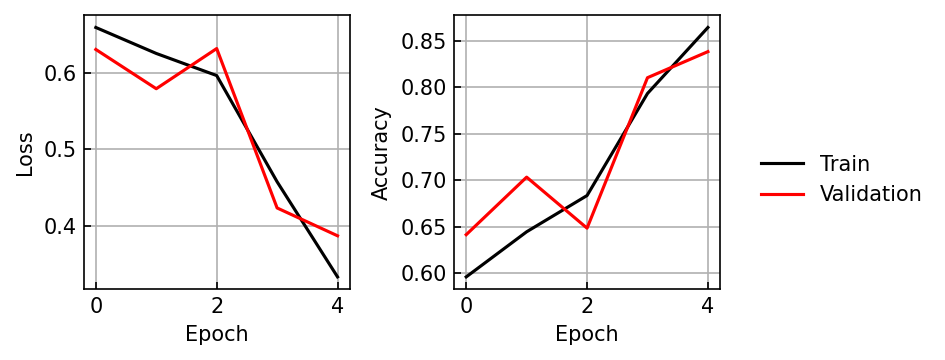

In [27]:
fig, ax = plt.subplots(1, 2, sharex=True, figsize=(5, 2.5))

ax[0].plot(model_stats[0], color='black', label='Train')
ax[0].plot(model_stats[2], color='red', label='Validation')
ax[0].set(xlabel='Epoch', ylabel='Loss')

ax[1].plot(model_stats[1], color='black', label='Train')
ax[1].plot(model_stats[3], color='red', label='Validation')
ax[1].set(xlabel='Epoch', ylabel='Accuracy')

fig.legend(*ax[1].get_legend_handles_labels(), 
           loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0)

plt.tight_layout()

In [28]:
model.eval()
with torch.no_grad():
    test_correct_ = 0.
    for xb, yb, lengths in tqdm(test_loader,leave=False):
        xb = xb.to(device)
        yb = yb.to(device)
        y_pred = model(xb, lengths.cpu().numpy())
        y_pred = torch.argmax(y_pred, dim=1)
        test_correct_ += (y_pred == yb).float().sum().item()
    test_acc = test_correct_ / len(test_loader.dataset)

print(f"Test accuracy: {test_acc:.3f}")

Test accuracy: 0.827


In [29]:
# Classify a single example
idx = np.random.choice(len(test_dataset))
sample = test_dataset[idx]
text = sample['text']
print('Comment:', text)
print()
print('True sentiment:', sample['label'])

# Convert comment with tokenizer, etc.
model.eval()
batch = collate_fn([sample,])
with torch.no_grad():
    y_pred = model(batch[0].to(device), batch[2])
    y_pred = F.softmax(y_pred, dim=1)

print('Predicted probability:', y_pred[0].cpu().numpy())

Comment: The viewer who said he was disappointed seems to be wildly missing the point here. This is a superb movie, excellent and realistic portrayals of a middle class Jewish family in Brighton Beach, Brooklyn, of long ago. The nuances are perfect and I felt the casting of everyone was superior. I especially found the acting done by Judith Ivey just perfection---especially the speech she has with her daughter when the daughter comes home late one night. That scene was Oscar worthy. But, really, all the acting was fine. I recommend this movie. It is a fun, family film and delightful to see how a lovely middle class family lived in Brooklyn so long ago. See it and you will be glad you did. Has some very funny lines and the Eugene character is a real comedian--very funny.

True sentiment: 1
Predicted probability: [0.0191 0.9809]


## Implementing an LSTM cell

In [30]:
x_seq = torch.FloatTensor([[1,], [2,], [3,]])
x_seq = x_seq.repeat(1, 2)
print(f"x_seq has shape {x_seq.shape} which means it is a sequence of {x_seq.shape[0]} {x_seq.shape[1]}-dimensional vectors")

x_seq has shape torch.Size([3, 2]) which means it is a sequence of 3 2-dimensional vectors


An LSTM has a hidden state $h^{(t)}$ and a cell state $c^{(t)}$.
It contains a set of **gating functions** that allow the model to input/update ($i^{(t)}$), forget ($f^{(t)}$), and output ($o^{(t)}$)

Each gate ($i^{(t)},f^{(t)},o^{(t)}$ each receive inputs from the previous hidden state $h^{(t-1)}$ and the current input $x^{(t)}$

The gating functions are given by
\begin{align}
    i^{(t)} &= \sigma\left( W_{ii} x^{(t)} + b_{ii} + W_{hi} h^{(t-1)} + b_{hi} \right) \\
    f^{(t)} &= \sigma\left( W_{if} x^{(t)} + b_{if} + W_{hf} h^{(t-1)} + b_{hf} \right) \\
    o^{(t)} &= \sigma\left( W_{io} x^{(t)} + b_{io} + W_{ho} h^{(t-1)} + b_{ho} \right) \\
\end{align}

There is also a cell input $g^{(t)}$
\begin{align}
    g^{(t)} &= \tanh \left( W_{ig} x^{(t)} + b_{ig} + W_{hg} h^{(t-1)} + b_{hg} \right) \\
\end{align}

The **cell state** $c^{(t)}$ uses the **forget gate** to determine whether to discard the previous cell state $c^{(t-1)}$ and the **input gate** to determine whether to accept the new input $g^{(t)}$

\begin{align}
    c^{(t)} &= f^{(t)} c^{(t-1)} + i^{(t)} g^{(t)}
\end{align}

The **hidden** state of the LSTM is then the product of the activated cell state and the output gate.
\begin{align}
    h^{(t)} &= o^{(t)} \tanh c^{(t)}
\end{align}

In [31]:
import torch.nn as nn
import torch.nn.functional as F

class LSTM_Cell(nn.Module):
    def __init__(self, input_size=2, hidden_size=4):
        super().__init__()

        self.hidden_size = hidden_size

        # Input gate weight and biases
        self.w_ii = nn.Parameter(torch.randn(size=(hidden_size, input_size)))
        self.b_ii = nn.Parameter(torch.zeros(hidden_size))

        self.w_ih = nn.Parameter(torch.randn(size=(hidden_size, hidden_size)))
        self.b_ih = nn.Parameter(torch.zeros(hidden_size))

        # Forget gate weight and biases
        self.w_fi = nn.Parameter(torch.randn(size=(hidden_size, input_size)))
        self.b_fi = nn.Parameter(torch.zeros(hidden_size))

        self.w_fh = nn.Parameter(torch.randn(size=(hidden_size, hidden_size)))
        self.b_fh = nn.Parameter(torch.zeros(hidden_size))

        # Cell input weight and biases
        self.w_gi = nn.Parameter(torch.randn(size=(hidden_size, input_size)))
        self.b_gi = nn.Parameter(torch.zeros(hidden_size))

        self.w_gh = nn.Parameter(torch.randn(size=(hidden_size, hidden_size)))
        self.b_gh = nn.Parameter(torch.zeros(hidden_size))
        
        # Output gate weight and biases
        self.w_oi = nn.Parameter(torch.randn(size=(hidden_size, input_size)))
        self.b_oi = nn.Parameter(torch.zeros(hidden_size))

        self.w_oh = nn.Parameter(torch.randn(size=(hidden_size, hidden_size)))
        self.b_oh = nn.Parameter(torch.zeros(hidden_size))
        
    def forward(self, x):
        """ x has size [B, t, c]
        """
        B, T, C = x.shape
        ht = torch.zeros([B, self.hidden_size], device=x.device, dtype=x.dtype)
        ct = torch.zeros([B, self.hidden_size], device=x.device, dtype=x.dtype)
        outputs = torch.zeros([B, T, self.hidden_size], device=x.device, dtype=x.dtype)
        for t in range(T):
            xt = x[:, t, :]
            print(f'At t = {t}')
            print(f'\tInput = {xt.numpy()}')

            # Compute the input/forget gates and cell inputs
            it = F.sigmoid(
                xt @ self.w_ii.T + self.b_ii + \
                ht @ self.w_ih.T + self.b_ih
            )
            ft = F.sigmoid(
                xt @ self.w_fi.T + self.b_fi + \
                ht @ self.w_fh.T + self.b_fh
            )
            gt = F.tanh(
                xt @ self.w_gi.T + self.b_gi + \
                ht @ self.w_gh.T + self.b_gh
            )

            # Compute the cell state
            ct = ft * ct + it * gt
            print(f'\tCell = {ct.detach().numpy()}')

            # Use the output gate to determine the hidden state
            ot = F.sigmoid(
                xt @ self.w_oi.T + self.b_oi + \
                ht @ self.w_oh.T + self.b_oh
            )
            ht = ot * F.tanh(ct)
            print(f'\tHidden = {ht.detach().numpy()}')
            outputs[:, t, :] = ht
        return outputs, (ht, ct)

torch_LSTM = nn.LSTM(input_size=2, hidden_size=4, batch_first=True)
print("Ground truth")
print("------------")
output, (hidden, cell) = torch_LSTM(x_seq[None])
print(f"Output is of size {output.shape}")
print(output)
print()
print(f"Last hidden is of size {hidden.shape}")
print(hidden)
print()
print(f"Last cell is of size {cell.shape}")
print(cell)

print()
print("Our implementation")
print("------------------")
np.set_printoptions(precision=4)
lstm = LSTM_Cell()
with torch.no_grad():
    lstm.w_ii[:] = torch_LSTM.weight_ih_l0[0:4]
    lstm.b_ii[:] = torch_LSTM.bias_ih_l0[0:4]
    lstm.w_ih[:] = torch_LSTM.weight_hh_l0[0:4]
    lstm.b_ih[:] = torch_LSTM.bias_hh_l0[0:4]

    lstm.w_fi[:] = torch_LSTM.weight_ih_l0[4:8]
    lstm.b_fi[:] = torch_LSTM.bias_ih_l0[4:8]
    lstm.w_fh[:] = torch_LSTM.weight_hh_l0[4:8]
    lstm.b_fh[:] = torch_LSTM.bias_hh_l0[4:8]

    lstm.w_gi[:] = torch_LSTM.weight_ih_l0[8:12]
    lstm.b_gi[:] = torch_LSTM.bias_ih_l0[8:12]
    lstm.w_gh[:] = torch_LSTM.weight_hh_l0[8:12]
    lstm.b_gh[:] = torch_LSTM.bias_hh_l0[8:12]

    lstm.w_oi[:] = torch_LSTM.weight_ih_l0[12:16]
    lstm.b_oi[:] = torch_LSTM.bias_ih_l0[12:16]
    lstm.w_oh[:] = torch_LSTM.weight_hh_l0[12:16]
    lstm.b_oh[:] = torch_LSTM.bias_hh_l0[12:16]

output, (hidden, cell) = lstm(x_seq[None])

print()
print(f"Output is of size {output.shape}")
print(output)
print()
print(f"Last hidden is of size {hidden.shape}")
print(hidden)
print()
print(f"Last cell is of size {cell.shape}")
print(cell)

Ground truth
------------
Output is of size torch.Size([1, 3, 4])
tensor([[[-0.2642,  0.0200,  0.0630,  0.1063],
         [-0.4587, -0.0703,  0.2850,  0.2072],
         [-0.5514, -0.1037,  0.5312,  0.2619]]], grad_fn=<TransposeBackward0>)

Last hidden is of size torch.Size([1, 1, 4])
tensor([[[-0.5514, -0.1037,  0.5312,  0.2619]]], grad_fn=<StackBackward0>)

Last cell is of size torch.Size([1, 1, 4])
tensor([[[-1.0459, -0.5602,  0.8806,  0.4411]]], grad_fn=<StackBackward0>)

Our implementation
------------------
At t = 0
	Input = [[1. 1.]]
	Cell = [[-0.4531  0.0476  0.1022  0.2563]]
	Hidden = [[-0.2642  0.02    0.063   0.1063]]
At t = 1
	Input = [[2. 2.]]
	Cell = [[-0.839  -0.2308  0.4326  0.4184]]
	Hidden = [[-0.4587 -0.0703  0.285   0.2072]]
At t = 2
	Input = [[3. 3.]]
	Cell = [[-1.0459 -0.5602  0.8806  0.4411]]
	Hidden = [[-0.5514 -0.1037  0.5312  0.2619]]

Output is of size torch.Size([1, 3, 4])
tensor([[[-0.2642,  0.0200,  0.0630,  0.1063],
         [-0.4587, -0.0703,  0.2850,  0.